# Graph Mining Project — IEEE 118 Cascade Analysis

This notebook contains a clean end-to-end workflow for the IEEE 118-bus case.

It includes:
- network loading and baseline power flow
- graph construction
- graph metrics for nodes and edges
- edge-triggered cascade simulation
- node-triggered cascade simulation
- comparison of graph metrics against simulation criticality
- sensitivity analysis
- the added node metrics: closeness and eigenvector centrality

## 1. Imports and experiment settings

In [1]:
import copy
from itertools import product

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn

from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

BASE_ALPHA = 0.20
BASE_MIN_LOADING = 0.10

## 2. Load the IEEE 300-bus system and solve the baseline operating point

In [2]:
net = pn.case300()
pp.runpp(net)

print("Buses:", len(net.bus))
print("Lines:", len(net.line))
print("Loads:", len(net.load))
print("Generators:", len(net.gen))
print("Baseline max line loading (%):", net.res_line.loading_percent.max())

Buses: 300
Lines: 283
Loads: 193
Generators: 68
Baseline max line loading (%): 8.732496523275994


## 3. Build the bus graph

In [3]:
def build_graph_from_net(net_obj):
    G = nx.Graph()

    for bus_id in net_obj.bus.index:
        G.add_node(int(bus_id))

    active_lines = net_obj.line[net_obj.line["in_service"] == True]

    for line_id, row in active_lines.iterrows():
        G.add_edge(
            int(row["from_bus"]),
            int(row["to_bus"]),
            line_id=int(line_id)
        )

    return G


G = build_graph_from_net(net)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 300
Edges: 281


## 4. Compute graph metrics

In [20]:
degree_dict = dict(G.degree())
node_betweenness_dict = nx.betweenness_centrality(G, normalized=True)
closeness_dict = nx.closeness_centrality(G)

try:
    eigenvector_dict = nx.eigenvector_centrality(G, max_iter=5000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge.")
    eigenvector_dict = {node: np.nan for node in G.nodes()}

edge_betweenness_raw = nx.edge_betweenness_centrality(G, normalized=True)

node_cent_df = pd.DataFrame({
    "bus_id": list(G.nodes()),
    "degree": [degree_dict[n] for n in G.nodes()],
    "node_betweenness": [node_betweenness_dict[n] for n in G.nodes()],
    "closeness": [closeness_dict[n] for n in G.nodes()],
    "eigenvector": [eigenvector_dict[n] for n in G.nodes()]
}).sort_values("node_betweenness", ascending=False)

edge_cent_rows = []
for (u, v), eb in edge_betweenness_raw.items():
    edge_cent_rows.append({
        "line_id": int(G[u][v]["line_id"]),
        "from_bus": int(u),
        "to_bus": int(v),
        "edge_betweenness": eb
    })

edge_cent_df = pd.DataFrame(edge_cent_rows).sort_values("edge_betweenness", ascending=False)

print("Top 10 nodes by node betweenness")
print(node_cent_df[["bus_id", "degree", "node_betweenness", "closeness", "eigenvector"]].head(10))

print("\nTop 10 edges by edge betweenness")
print(edge_cent_df.head(10))

top_degree_nodes = node_cent_df.sort_values("degree", ascending=False).head(10)

print("\nTop 10 buses by degree")
print(top_degree_nodes[["bus_id", "degree", "node_betweenness", "closeness", "eigenvector"]])

Top 10 nodes by node betweenness
    bus_id  degree  node_betweenness  closeness  eigenvector
40      40       3          0.035092   0.053755     0.016229
60      60       4          0.033400   0.049786     0.006374
37      37       3          0.026309   0.054250     0.047355
30      30       7          0.025040   0.053031     0.503937
14      14       4          0.024497   0.049267     0.263022
13      13       2          0.023232   0.044358     0.073829
7        7       3          0.022536   0.040202     0.022459
36      36       4          0.021631   0.054881     0.137256
10      10       3          0.018563   0.036418     0.006790
65      65       4          0.018507   0.044694     0.003064

Top 10 edges by edge betweenness
    line_id  from_bus  to_bus  edge_betweenness
61       73        40      60          0.033445
56       68        37      40          0.025739
16       28        13      14          0.024615
11       23         7      13          0.023411
53       65        36 

## 5. Cascade simulation helpers

In [5]:
def build_active_graph(net_obj):
    G_active = nx.Graph()

    for bus_id in net_obj.bus.index:
        G_active.add_node(int(bus_id))

    active_lines = net_obj.line[net_obj.line["in_service"] == True]

    for line_id, row in active_lines.iterrows():
        G_active.add_edge(
            int(row["from_bus"]),
            int(row["to_bus"]),
            line_id=int(line_id)
        )

    return G_active


def compute_load_shed(net_obj):
    total_load = net_obj.load["p_mw"].sum()

    active_buses = set()
    active_lines = net_obj.line[net_obj.line["in_service"] == True]

    for _, row in active_lines.iterrows():
        active_buses.add(int(row["from_bus"]))
        active_buses.add(int(row["to_bus"]))

    served_load = net_obj.load[net_obj.load["bus"].isin(active_buses)]["p_mw"].sum()
    shed_load = total_load - served_load
    shed_percent = 100.0 * shed_load / total_load if total_load > 0 else 0.0

    return served_load, shed_load, shed_percent


def run_cascade(net_obj, initial_line=None, initial_lines=None, alpha=0.20, min_base_loading=0.10):
    netc = copy.deepcopy(net_obj)

    baseline_loading = net_obj.res_line.loading_percent.copy()
    threshold = baseline_loading.clip(lower=min_base_loading) * (1.0 + alpha)

    if initial_lines is None:
        if initial_line is None:
            raise ValueError("Provide either initial_line or initial_lines")
        initial_lines = [int(initial_line)]
    else:
        initial_lines = [int(x) for x in initial_lines]

    tripped_lines = []

    for line_id in initial_lines:
        netc.line.at[line_id, "in_service"] = False
        tripped_lines.append(int(line_id))

    iterations = 0

    while True:
        iterations += 1

        try:
            pp.runpp(netc)
        except Exception:
            G_active = build_active_graph(netc)
            lcc_size = len(max(nx.connected_components(G_active), key=len)) if G_active.number_of_edges() > 0 else 1
            served_load, shed_load, shed_percent = compute_load_shed(netc)

            return {
                "initial_line": int(initial_lines[0]) if len(initial_lines) == 1 else None,
                "initial_lines": initial_lines,
                "cascade_size": len(tripped_lines),
                "tripped_lines": tripped_lines,
                "iterations": iterations,
                "solver_failed": True,
                "lcc_size": lcc_size,
                "served_load_mw": served_load,
                "shed_load_mw": shed_load,
                "shed_percent": shed_percent
            }

        current_loading = netc.res_line.loading_percent.copy()
        active_mask = netc.line["in_service"] == True
        overload_mask = active_mask & (current_loading > threshold)

        newly_overloaded = [
            int(line_id)
            for line_id in netc.line.index[overload_mask].tolist()
            if int(line_id) not in tripped_lines
        ]

        if len(newly_overloaded) == 0:
            break

        for line_id in newly_overloaded:
            netc.line.at[line_id, "in_service"] = False
            tripped_lines.append(int(line_id))

    G_active = build_active_graph(netc)
    lcc_size = len(max(nx.connected_components(G_active), key=len)) if G_active.number_of_edges() > 0 else 1
    served_load, shed_load, shed_percent = compute_load_shed(netc)

    return {
        "initial_line": int(initial_lines[0]) if len(initial_lines) == 1 else None,
        "initial_lines": initial_lines,
        "cascade_size": len(tripped_lines),
        "tripped_lines": tripped_lines,
        "iterations": iterations,
        "solver_failed": False,
        "lcc_size": lcc_size,
        "served_load_mw": served_load,
        "shed_load_mw": shed_load,
        "shed_percent": shed_percent
    }


def run_node_cascade(net_obj, bus_id, alpha=0.20, min_base_loading=0.10):
    incident_lines = net_obj.line.index[
        (net_obj.line["from_bus"] == bus_id) | (net_obj.line["to_bus"] == bus_id)
    ].tolist()

    result = run_cascade(
        net_obj,
        initial_lines=incident_lines,
        alpha=alpha,
        min_base_loading=min_base_loading
    )

    result["initial_bus"] = int(bus_id)
    result["incident_line_count"] = len(incident_lines)
    return result

In [6]:
sanity_result = run_cascade(net, initial_line=0, alpha=BASE_ALPHA, min_base_loading=BASE_MIN_LOADING)
print(sanity_result)

{'initial_line': 0, 'initial_lines': [0], 'cascade_size': 2, 'tripped_lines': [0, 57], 'iterations': 2, 'solver_failed': False, 'lcc_size': 85, 'served_load_mw': np.float64(19850.42), 'shed_load_mw': np.float64(3997.230000000003), 'shed_percent': np.float64(16.761525768786456)}


## 6. Full edge-triggered cascade scan

In [7]:
edge_results = []

for line_id in net.line.index:
    edge_results.append(
        run_cascade(
            net,
            initial_line=int(line_id),
            alpha=BASE_ALPHA,
            min_base_loading=BASE_MIN_LOADING
        )
    )

cascade_df = pd.DataFrame(edge_results)
print(cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(10))

     initial_line initial_lines  cascade_size                                      tripped_lines  iterations  solver_failed  lcc_size  served_load_mw  \
225           225         [225]            79  [225, 179, 181, 220, 221, 0, 14, 16, 17, 18, 1...           3          False        30        16283.52   
201           201         [201]            64  [201, 145, 149, 150, 151, 153, 156, 157, 202, ...           3          False        28        16847.52   
147           147         [147]            66  [147, 145, 146, 149, 150, 151, 152, 153, 156, ...           3          False        28        16987.82   
228           228         [228]            69  [228, 254, 261, 262, 267, 268, 269, 29, 30, 31...           4           True        34        17583.22   
269           269         [269]            74  [269, 228, 257, 258, 259, 261, 263, 268, 29, 3...           4           True        34        17586.22   
263           263         [263]            42  [263, 228, 258, 260, 261, 265, 268,

## 7. Compare edge betweenness against simulated edge criticality

In [8]:
edge_compare_df = edge_cent_df.merge(
    cascade_df[["initial_line", "cascade_size", "shed_percent", "lcc_size", "solver_failed"]],
    left_on="line_id",
    right_on="initial_line",
    how="left"
)

valid_edge_compare = edge_compare_df[edge_compare_df["solver_failed"] == False].copy()

edge_summary = pd.DataFrame([{
    "pearson_betweenness_vs_shed": pearsonr(valid_edge_compare["edge_betweenness"], valid_edge_compare["shed_percent"])[0],
    "spearman_betweenness_vs_shed": spearmanr(valid_edge_compare["edge_betweenness"], valid_edge_compare["shed_percent"])[0],
    "pearson_betweenness_vs_cascade": pearsonr(valid_edge_compare["edge_betweenness"], valid_edge_compare["cascade_size"])[0],
    "spearman_betweenness_vs_cascade": spearmanr(valid_edge_compare["edge_betweenness"], valid_edge_compare["cascade_size"])[0]
}])

print(edge_summary)
print("\nTop 15 edge comparison rows")
print(edge_compare_df.sort_values(["shed_percent", "cascade_size", "edge_betweenness"], ascending=False).head(15))

   pearson_betweenness_vs_shed  spearman_betweenness_vs_shed  pearson_betweenness_vs_cascade  spearman_betweenness_vs_cascade
0                    -0.090316                     -0.045879                       -0.060788                        -0.021118

Top 15 edge comparison rows
     line_id  from_bus  to_bus  edge_betweenness  initial_line  cascade_size  shed_percent  lcc_size  solver_failed
171      225       116     166          0.000386           225            79     31.718555        30          False
264      201       135     137          0.000067           201            64     29.353542        28          False
233      147        95      96          0.000134           147            66     28.765224        28          False
189      228       168     209          0.000290           228            69     26.268542        34           True
158      269       209     215          0.000535           269            74     26.255962        34           True
179      263       199 

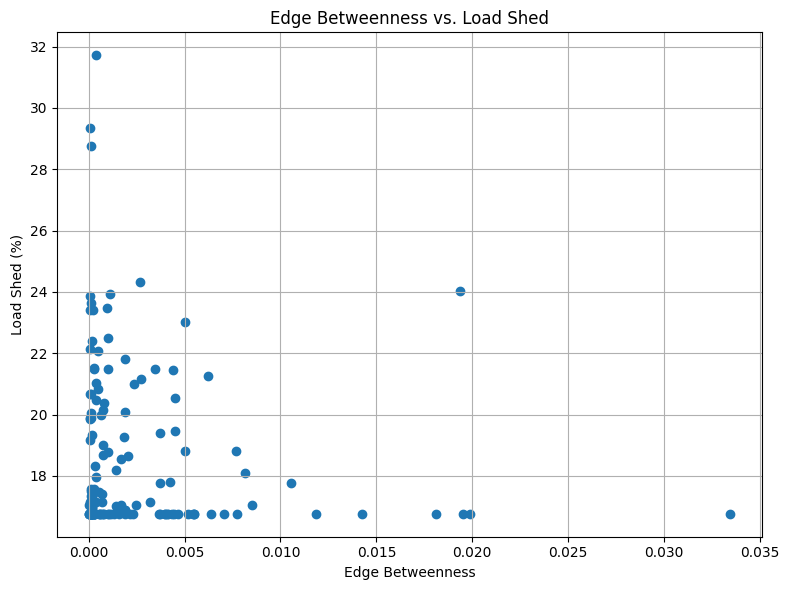

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(valid_edge_compare["edge_betweenness"], valid_edge_compare["shed_percent"])
plt.xlabel("Edge Betweenness")
plt.ylabel("Load Shed (%)")
plt.title("Edge Betweenness vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Full node-triggered cascade scan

In [10]:
node_results = []

for bus_id in net.bus.index:
    node_results.append(
        run_node_cascade(
            net,
            bus_id=int(bus_id),
            alpha=BASE_ALPHA,
            min_base_loading=BASE_MIN_LOADING
        )
    )

node_cascade_df = pd.DataFrame(node_results)
print(node_cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(15))

     initial_line         initial_lines  cascade_size                                      tripped_lines  iterations  solver_failed  lcc_size  served_load_mw  \
137           NaN            [201, 202]            67  [201, 202, 145, 146, 149, 150, 151, 153, 155, ...           3          False        28        16847.52   
135         201.0                 [201]            64  [201, 145, 149, 150, 151, 153, 156, 157, 202, ...           3          False        28        16847.52   
116           NaN            [220, 225]            73  [220, 225, 0, 14, 16, 17, 18, 19, 20, 21, 22, ...           2          False        44        16899.82   
95          147.0                 [147]            66  [147, 145, 146, 149, 150, 151, 152, 153, 156, ...           3          False        28        16987.82   
18            NaN          [27, 35, 36]            70  [27, 35, 36, 20, 22, 39, 41, 42, 16, 29, 30, 3...           4          False        34        17214.32   
215           NaN            [259,

## 9. Compare node metrics against simulated node criticality

In [11]:
node_compare_df = node_cent_df.merge(
    node_cascade_df[["initial_bus", "incident_line_count", "cascade_size", "shed_percent", "lcc_size", "solver_failed"]],
    left_on="bus_id",
    right_on="initial_bus",
    how="left"
)

valid_node_compare = node_compare_df[node_compare_df["solver_failed"] == False].copy()

print("Top 15 node comparison rows")
print(valid_node_compare.sort_values(["shed_percent", "cascade_size"], ascending=False).head(15))

Top 15 node comparison rows
     bus_id  degree  node_betweenness  closeness   eigenvector  initial_bus  incident_line_count  cascade_size  shed_percent  lcc_size  solver_failed
155     137       2          0.000045   0.007525  1.649029e-39          137                    2            67     29.353542        28          False
230     135       1          0.000000   0.005017  1.019156e-39          135                    1            64     29.353542        28          False
161     116       2          0.000007   0.026392  1.255211e-04          116                    2            73     29.134233        44          False
243      95       1          0.000000   0.008600  1.794003e-19           95                    1            66     28.765224        28          False
16       18       3          0.010561   0.029948  5.765319e-04           18                    3            70     27.815445        34          False
93      215       2          0.000494   0.011775  2.857517e-23          

In [12]:
def safe_corr(x, y, method="pearson"):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(df) < 2:
        return np.nan
    if method == "pearson":
        return pearsonr(df["x"], df["y"])[0]
    if method == "spearman":
        return spearmanr(df["x"], df["y"])[0]
    raise ValueError("method must be 'pearson' or 'spearman'")


metrics_to_test = ["degree", "node_betweenness", "closeness", "eigenvector"]
targets_to_test = ["shed_percent", "cascade_size"]

node_metric_rows = []

for metric in metrics_to_test:
    for target in targets_to_test:
        node_metric_rows.append({
            "metric": metric,
            "target": target,
            "pearson": safe_corr(valid_node_compare[metric], valid_node_compare[target], method="pearson"),
            "spearman": safe_corr(valid_node_compare[metric], valid_node_compare[target], method="spearman")
        })

node_metric_results_df = pd.DataFrame(node_metric_rows)
print(node_metric_results_df.sort_values(["target", "spearman"], ascending=False))

             metric        target   pearson  spearman
0            degree  shed_percent  0.405637  0.747169
4         closeness  shed_percent  0.226542  0.676267
6       eigenvector  shed_percent -0.046565  0.658854
2  node_betweenness  shed_percent  0.123619  0.626020
1            degree  cascade_size  0.545163  0.793540
5         closeness  cascade_size  0.395130  0.716611
7       eigenvector  cascade_size  0.048297  0.700899
3  node_betweenness  cascade_size  0.282330  0.648111


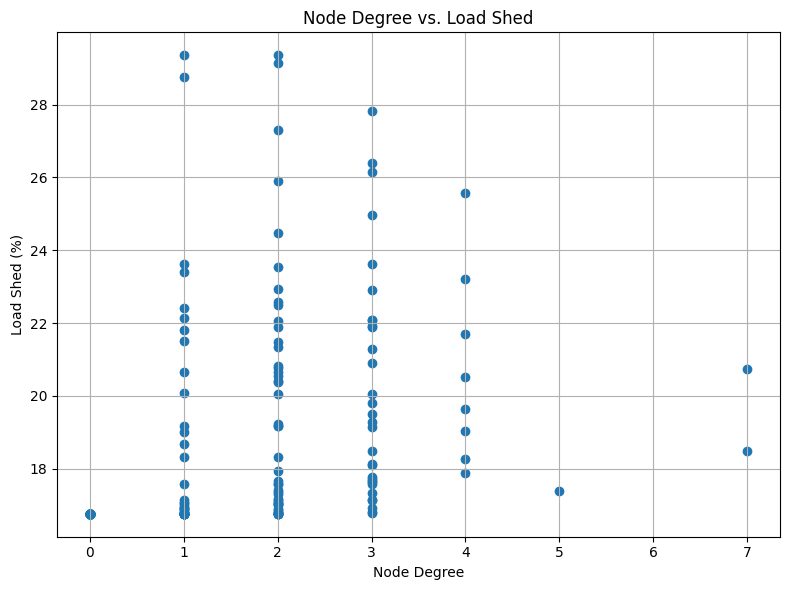

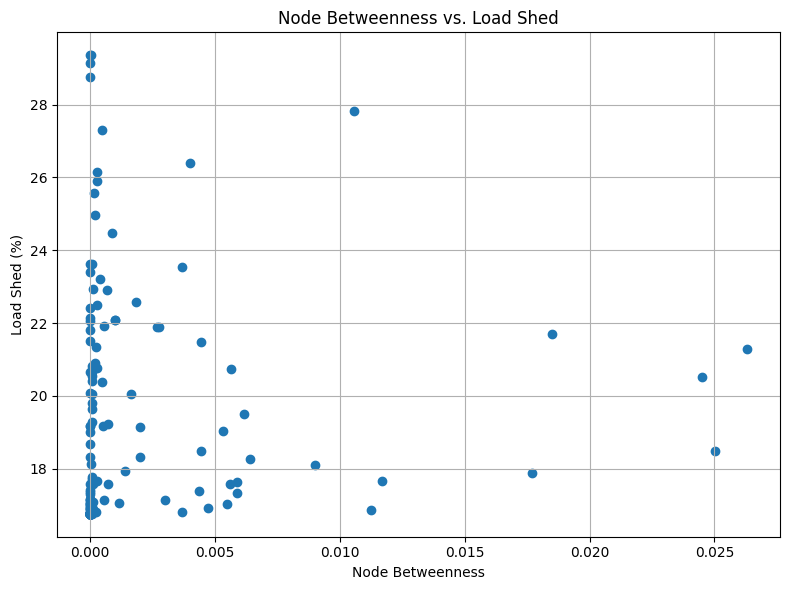

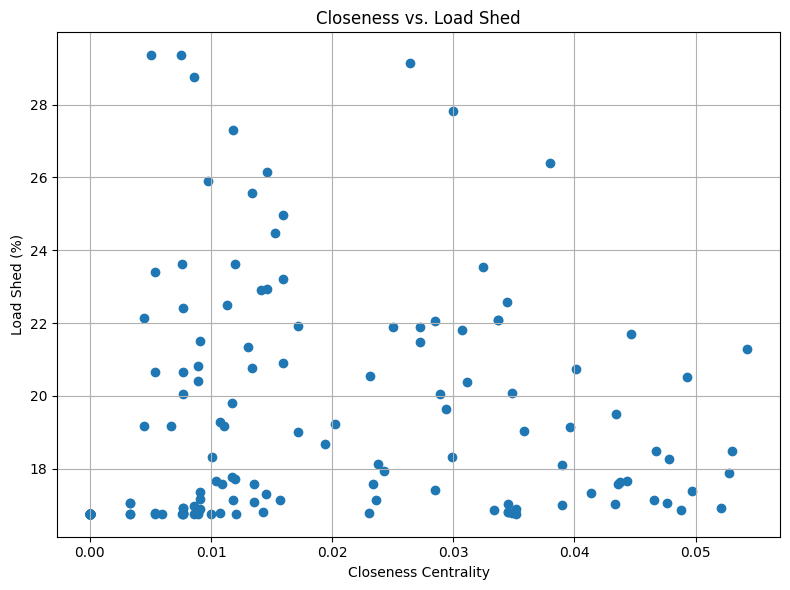

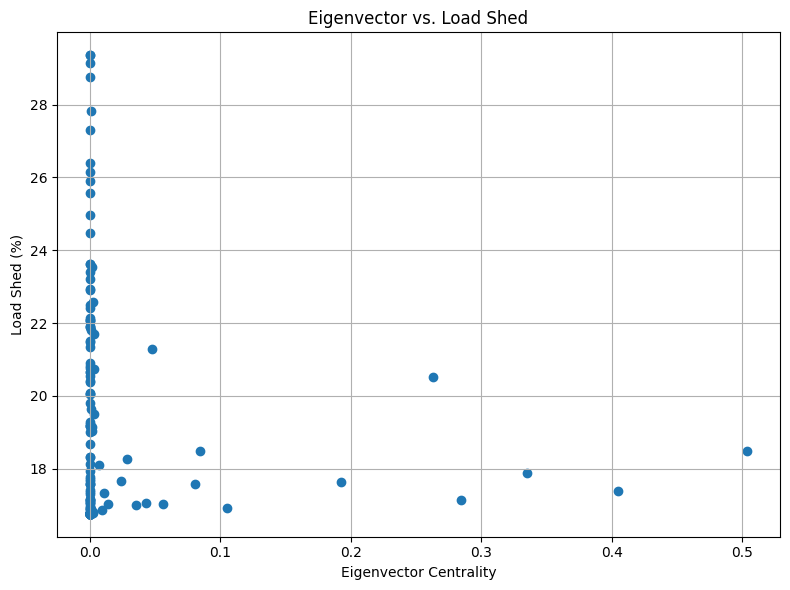

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["degree"], valid_node_compare["shed_percent"])
plt.xlabel("Node Degree")
plt.ylabel("Load Shed (%)")
plt.title("Node Degree vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["node_betweenness"], valid_node_compare["shed_percent"])
plt.xlabel("Node Betweenness")
plt.ylabel("Load Shed (%)")
plt.title("Node Betweenness vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["closeness"], valid_node_compare["shed_percent"])
plt.xlabel("Closeness Centrality")
plt.ylabel("Load Shed (%)")
plt.title("Closeness vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(valid_node_compare["eigenvector"], valid_node_compare["shed_percent"])
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Load Shed (%)")
plt.title("Eigenvector vs. Load Shed")
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Top-10 overlap checks for node metrics

In [14]:
def top_k_overlap(df, metric_col, target_col, k=10):
    top_metric = set(df.nlargest(k, metric_col)["bus_id"])
    top_target = set(df.nlargest(k, target_col)["bus_id"])
    overlap = len(top_metric & top_target)
    union = len(top_metric | top_target)
    jaccard = overlap / union if union > 0 else np.nan
    return overlap, jaccard, top_metric, top_target


overlap_rows = []

for metric in metrics_to_test:
    overlap_shed, jaccard_shed, top_metric_shed, top_target_shed = top_k_overlap(
        valid_node_compare, metric, "shed_percent", k=10
    )
    overlap_cascade, jaccard_cascade, top_metric_cascade, top_target_cascade = top_k_overlap(
        valid_node_compare, metric, "cascade_size", k=10
    )

    overlap_rows.append({
        "metric": metric,
        "top10_overlap_vs_shed": overlap_shed,
        "top10_jaccard_vs_shed": jaccard_shed,
        "top10_overlap_vs_cascade": overlap_cascade,
        "top10_jaccard_vs_cascade": jaccard_cascade
    })

overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df.sort_values("top10_overlap_vs_shed", ascending=False))

             metric  top10_overlap_vs_shed  top10_jaccard_vs_shed  top10_overlap_vs_cascade  top10_jaccard_vs_cascade
0            degree                      1               0.052632                         0                  0.000000
1  node_betweenness                      1               0.052632                         1                  0.052632
2         closeness                      0               0.000000                         0                  0.000000
3       eigenvector                      0               0.000000                         0                  0.000000


## 11. Combined summary table for node metrics

In [15]:
summary_rows = []

for metric in metrics_to_test:
    overlap_shed, jaccard_shed, _, _ = top_k_overlap(valid_node_compare, metric, "shed_percent", k=10)
    overlap_cascade, jaccard_cascade, _, _ = top_k_overlap(valid_node_compare, metric, "cascade_size", k=10)

    summary_rows.append({
        "metric": metric,
        "pearson_vs_shed": safe_corr(valid_node_compare[metric], valid_node_compare["shed_percent"], method="pearson"),
        "spearman_vs_shed": safe_corr(valid_node_compare[metric], valid_node_compare["shed_percent"], method="spearman"),
        "pearson_vs_cascade": safe_corr(valid_node_compare[metric], valid_node_compare["cascade_size"], method="pearson"),
        "spearman_vs_cascade": safe_corr(valid_node_compare[metric], valid_node_compare["cascade_size"], method="spearman"),
        "top10_overlap_vs_shed": overlap_shed,
        "top10_jaccard_vs_shed": jaccard_shed,
        "top10_overlap_vs_cascade": overlap_cascade,
        "top10_jaccard_vs_cascade": jaccard_cascade
    })

node_metric_summary_df = pd.DataFrame(summary_rows)
print(node_metric_summary_df.sort_values("spearman_vs_shed", ascending=False))

             metric  pearson_vs_shed  spearman_vs_shed  pearson_vs_cascade  spearman_vs_cascade  top10_overlap_vs_shed  top10_jaccard_vs_shed  \
0            degree         0.405637          0.747169            0.545163             0.793540                      1               0.052632   
2         closeness         0.226542          0.676267            0.395130             0.716611                      0               0.000000   
3       eigenvector        -0.046565          0.658854            0.048297             0.700899                      0               0.000000   
1  node_betweenness         0.123619          0.626020            0.282330             0.648111                      1               0.052632   

   top10_overlap_vs_cascade  top10_jaccard_vs_cascade  
0                         0                  0.000000  
2                         0                  0.000000  
3                         0                  0.000000  
1                         1                  0.052

## 12. Sensitivity sweep

In [16]:
def evaluate_edge_setting(net_obj, edge_cent_df, alpha, min_base_loading):
    results = []

    for line_id in net_obj.line.index:
        results.append(
            run_cascade(
                net_obj,
                initial_line=int(line_id),
                alpha=alpha,
                min_base_loading=min_base_loading
            )
        )

    temp_df = pd.DataFrame(results)

    compare_df = edge_cent_df.merge(
        temp_df[["initial_line", "cascade_size", "shed_percent", "solver_failed"]],
        left_on="line_id",
        right_on="initial_line",
        how="left"
    )

    valid_df = compare_df[compare_df["solver_failed"] == False].copy()

    top10_metric = set(valid_df.nlargest(10, "edge_betweenness")["line_id"])
    top10_shed = set(valid_df.nlargest(10, "shed_percent")["line_id"])
    union = len(top10_metric | top10_shed)
    top10_overlap = len(top10_metric & top10_shed)
    top10_jaccard = top10_overlap / union if union > 0 else np.nan

    return {
        "alpha": alpha,
        "min_base_loading": min_base_loading,
        "mean_shed_percent": temp_df["shed_percent"].mean(),
        "max_shed_percent": temp_df["shed_percent"].max(),
        "mean_cascade_size": temp_df["cascade_size"].mean(),
        "max_cascade_size": temp_df["cascade_size"].max(),
        "spearman_betweenness_vs_shed": safe_corr(valid_df["edge_betweenness"], valid_df["shed_percent"], method="spearman"),
        "spearman_betweenness_vs_cascade": safe_corr(valid_df["edge_betweenness"], valid_df["cascade_size"], method="spearman"),
        "top10_overlap": top10_overlap,
        "top10_jaccard": top10_jaccard
    }


alphas = [0.10, 0.20, 0.30, 0.40]
min_base_loadings = [0.01, 0.05, 0.10]

sweep_rows = []

for alpha, min_base_loading in product(alphas, min_base_loadings):
    sweep_rows.append(evaluate_edge_setting(net, edge_cent_df, alpha, min_base_loading))

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.sort_values(["mean_shed_percent", "max_shed_percent"], ascending=False))

    alpha  min_base_loading  mean_shed_percent  max_shed_percent  mean_cascade_size  max_cascade_size  spearman_betweenness_vs_shed  \
0     0.1              0.01          19.190539         30.599367          33.950530               119                      0.078549   
1     0.1              0.05          19.167049         30.598948          33.395760               119                      0.086641   
2     0.1              0.10          19.113093         30.545274          31.250883               128                      0.048557   
3     0.2              0.01          18.484722         31.812485          23.282686               125                     -0.044046   
4     0.2              0.05          18.473767         31.812485          22.911661               124                     -0.045472   
5     0.2              0.10          18.337076         31.718555          20.515901                85                     -0.045879   
6     0.3              0.01          17.872066         

## 13. Sensitivity heatmaps

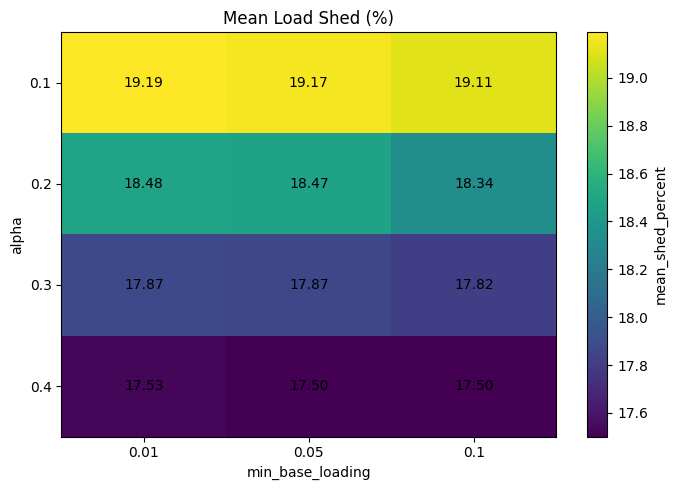

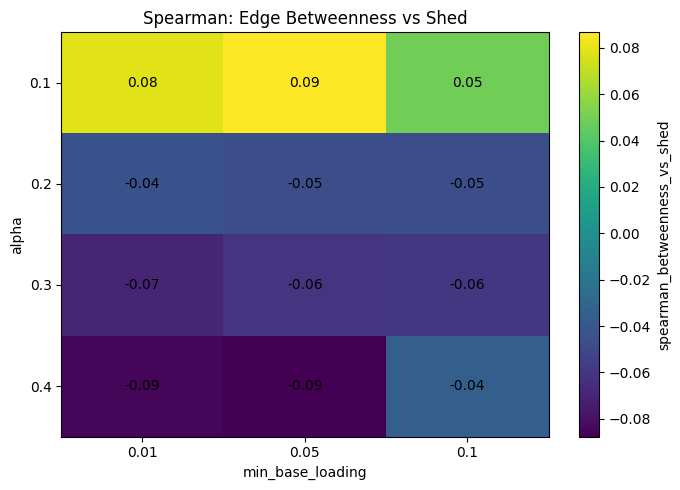

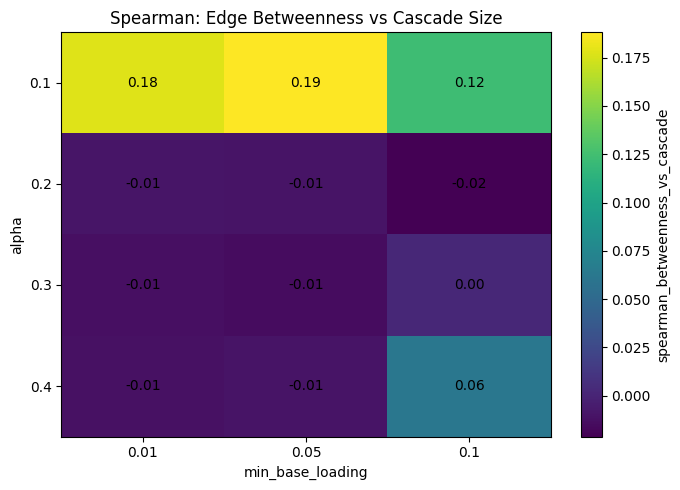

In [17]:
def plot_heatmap(df, value_col, title):
    pivot = df.pivot(index="alpha", columns="min_base_loading", values=value_col)

    plt.figure(figsize=(7, 5))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    plt.xlabel("min_base_loading")
    plt.ylabel("alpha")
    plt.title(title)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()
    return pivot


mean_shed_pivot = plot_heatmap(sweep_df, "mean_shed_percent", "Mean Load Shed (%)")
spearman_shed_pivot = plot_heatmap(sweep_df, "spearman_betweenness_vs_shed", "Spearman: Edge Betweenness vs Shed")
spearman_cascade_pivot = plot_heatmap(sweep_df, "spearman_betweenness_vs_cascade", "Spearman: Edge Betweenness vs Cascade Size")

## 14. Final quick-access tables

In [18]:
top_edge_failures = cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(10)
top_node_failures = node_cascade_df.sort_values(["shed_percent", "cascade_size"], ascending=False).head(10)

print("Top 10 edge-triggered cascades")
print(top_edge_failures)

print("\nTop 10 node-triggered cascades")
print(top_node_failures)

print("\nNode metric summary")
print(node_metric_summary_df.sort_values("spearman_vs_shed", ascending=False))

Top 10 edge-triggered cascades
     initial_line initial_lines  cascade_size                                      tripped_lines  iterations  solver_failed  lcc_size  served_load_mw  \
225           225         [225]            79  [225, 179, 181, 220, 221, 0, 14, 16, 17, 18, 1...           3          False        30        16283.52   
201           201         [201]            64  [201, 145, 149, 150, 151, 153, 156, 157, 202, ...           3          False        28        16847.52   
147           147         [147]            66  [147, 145, 146, 149, 150, 151, 152, 153, 156, ...           3          False        28        16987.82   
228           228         [228]            69  [228, 254, 261, 262, 267, 268, 269, 29, 30, 31...           4           True        34        17583.22   
269           269         [269]            74  [269, 228, 257, 258, 259, 261, 263, 268, 29, 3...           4           True        34        17586.22   
263           263         [263]            42  [263